# Machine Learning Essentials - Exercise 3

## Part 1: Introduction

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision.datasets as datasets
import torchvision.transforms as transforms

from torch.nn.functional import conv2d, max_pool2d, cross_entropy

### Load MNIST

In [2]:
plt.rc("figure", dpi=100)

batch_size = 100

# transform images into normalized tensors
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

train_dataset = datasets.MNIST(
    "./",
    download=True,
    train=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    "./",
    download=True,
    train=False,
    transform=transform,
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=1,
    pin_memory=True,
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=1,
    pin_memory=True,
)

### Helper functions

In [3]:
def init_weights(shape):
    # Kaiming He initialization (a good initialization is important)
    # https://arxiv.org/abs/1502.01852
    std = np.sqrt(2. / shape[0])
    w = torch.randn(size=shape) * std
    w.requires_grad = True
    return w


def rectify(x):
    # Rectified Linear Unit (ReLU)
    return torch.max(torch.zeros_like(x), x)

class RMSprop(optim.Optimizer):
    """
        This is a reduced version of the PyTorch internal RMSprop optimizer
        It serves here as an example
    """
    def __init__(self, params, lr=1e-3, alpha=0.5, eps=1e-8):
        defaults = dict(lr=lr, alpha=alpha, eps=eps)
        super(RMSprop, self).__init__(params, defaults)

    def step(self):
        for group in self.param_groups:
            for p in group['params']:
                grad = p.grad.data
                state = self.state[p]

                # state initialization
                if len(state) == 0:
                    state['square_avg'] = torch.zeros_like(p.data)

                square_avg = state['square_avg']
                alpha = group['alpha']

                # update running averages
                square_avg.mul_(alpha).addcmul_(grad, grad, value=1 - alpha)
                avg = square_avg.sqrt().add_(group['eps'])

                # gradient update
                p.data.addcdiv_(grad, avg, value=-group['lr'])


### Model

In [4]:
# define the neural network
def model(x, w_h, w_h2, w_o):
    h = rectify(x @ w_h)
    h2 = rectify(h @ w_h2)
    pre_softmax = h2 @ w_o
    return pre_softmax

### Initialize weights

In [5]:
# input shape is (B, 784)
w_h = init_weights((784, 625))
# hidden layer with 625 neurons
w_h2 = init_weights((625, 625))
# hidden layer with 625 neurons
w_o = init_weights((625, 10))
# output shape is (B, 10)

### Training Loop

In [6]:
optimizer = RMSprop(params=[w_h, w_h2, w_o])

n_epochs = 100

train_loss = []
test_loss = []

# put this into a training loop over 100 epochs
for epoch in range(n_epochs + 1):
    train_loss_this_epoch = []
    for idx, batch in enumerate(train_dataloader):
        x, y = batch

        # our model requires flattened input
        x = x.reshape(batch_size, 784)
        # feed input through model
        noise_py_x = model(x, w_h, w_h2, w_o)

        # reset the gradient
        optimizer.zero_grad()

        # the cross-entropy loss function already contains the softmax
        loss = cross_entropy(noise_py_x, y, reduction="mean")

        train_loss_this_epoch.append(float(loss))

        # compute the gradient
        loss.backward()
        # update weights
        optimizer.step()

    train_loss.append(np.mean(train_loss_this_epoch))

    # test periodically
    if epoch % 10 == 0:
        print(f"Epoch: {epoch}")
        print(f"Mean Train Loss: {train_loss[-1]:.2e}")
        test_loss_this_epoch = []

        # no need to compute gradients for validation
        with torch.no_grad():
            for idx, batch in enumerate(test_dataloader):
                x, y = batch
                x = x.reshape(batch_size, 784)
                noise_py_x = model(x, w_h, w_h2, w_o)

                loss = cross_entropy(noise_py_x, y, reduction="mean")
                test_loss_this_epoch.append(float(loss))

        test_loss.append(np.mean(test_loss_this_epoch))

        print(f"Mean Test Loss:  {test_loss[-1]:.2e}")

Epoch: 0
Mean Train Loss: 4.03e-01
Mean Test Loss:  2.09e-01
Epoch: 10
Mean Train Loss: 1.43e-01
Mean Test Loss:  3.42e-01
Epoch: 20
Mean Train Loss: 1.00e-01
Mean Test Loss:  4.82e-01
Epoch: 30
Mean Train Loss: 6.35e-02
Mean Test Loss:  6.03e-01
Epoch: 40
Mean Train Loss: 4.16e-02
Mean Test Loss:  5.29e-01
Epoch: 50
Mean Train Loss: 3.03e-02
Mean Test Loss:  7.40e-01
Epoch: 60
Mean Train Loss: 3.03e-02
Mean Test Loss:  9.12e-01
Epoch: 70
Mean Train Loss: 2.10e-02
Mean Test Loss:  9.32e-01
Epoch: 80
Mean Train Loss: 1.41e-02
Mean Test Loss:  7.56e-01
Epoch: 90
Mean Train Loss: 4.82e-03
Mean Test Loss:  9.11e-01
Epoch: 100
Mean Train Loss: 7.07e-03
Mean Test Loss:  9.01e-01


### Plot Losses

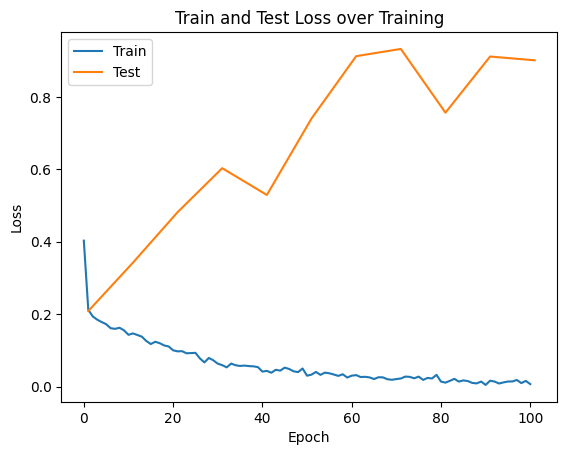

In [7]:
plt.plot(np.arange(n_epochs + 1), train_loss, label="Train")
plt.plot(np.arange(1, n_epochs + 2, 10), test_loss, label="Test")
plt.title("Train and Test Loss over Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

## Part 2: Dropout

In [8]:
def dropout(X, p_drop=0.5):
    # p_drop must be in (0, 1)
    if 0 < p_drop < 1:
        # one random drop decision per element
        drop_mask = torch.bernoulli(torch.ones_like(X) * p_drop)
        keep_mask = 1.0 - drop_mask
        kept_X = X * keep_mask
        return kept_X / (1.0 - p_drop)
    else:
        return X


### Build new model with dropout functionality

In [9]:
def dropout_model(X, w_h, w_h2, w_o, p_drop_input, p_drop_hidden):
    X = dropout(X, p_drop_input)

    h = rectify(X @ w_h)

    h = dropout(h, p_drop_hidden)

    h2 = rectify(h @ w_h2)

    h2 = dropout(h2, p_drop_hidden)

    return h2 @ w_o


Dropout method randomly sets some neuron outputs to `0` (deactivate) during training. The remaining active neurons are scaled up so that the total expected output stays the same.

This helps to reduce overfitting because the network cannot rely on the same neurons every time. Instead, it must learn more robust features that work well even when some connections are missing. In other words, dropout behaves like training many slightly different networks and averaging their behavior.

### Train the model using dropout and report train and test errors

In [10]:
# reinitializing weights
w_h = init_weights((784, 625))
w_h2 = init_weights((625, 625))
w_o = init_weights((625, 10))

p_drop_input = 0.2
p_drop_hidden = 0.5

optimizer = RMSprop(params=[w_h, w_h2, w_o])

n_epochs = 100

train_loss = []
test_loss = []

# put this into a training loop over 100 epochs
for epoch in range(n_epochs + 1):
    train_loss_this_epoch = []
    for idx, batch in enumerate(train_dataloader):
        x, y = batch

        # our model requires flattened input
        x = x.reshape(batch_size, 784)
        # feed input through model
        noise_py_x = dropout_model(x, w_h, w_h2, w_o, p_drop_input, p_drop_hidden)

        # reset the gradient
        optimizer.zero_grad()

        # the cross-entropy loss function already contains the softmax
        loss = cross_entropy(noise_py_x, y, reduction="mean")

        train_loss_this_epoch.append(float(loss))

        # compute the gradient
        loss.backward()
        # update weights
        optimizer.step()

    train_loss.append(np.mean(train_loss_this_epoch))

    # test periodically
    if epoch % 10 == 0:
        print(f"Epoch: {epoch}")
        print(f"Mean Train Loss for the Dropout Model: {train_loss[-1]:.2e}")
        test_loss_this_epoch = []

        # no need to compute gradients for validation
        with torch.no_grad():
            for idx, batch in enumerate(test_dataloader):
                x, y = batch
                x = x.reshape(batch_size, 784)
                noise_py_x = model(x, w_h, w_h2, w_o)

                loss = cross_entropy(noise_py_x, y, reduction="mean")
                test_loss_this_epoch.append(float(loss))

        test_loss.append(np.mean(test_loss_this_epoch))

        print(f"Mean Test Loss for the Dropout Model:  {test_loss[-1]:.2e}")

Epoch: 0
Mean Train Loss for the Dropout Model: 7.45e-01
Mean Test Loss for the Dropout Model:  2.39e-01
Epoch: 10
Mean Train Loss for the Dropout Model: 6.90e-01
Mean Test Loss for the Dropout Model:  2.18e-01
Epoch: 20
Mean Train Loss for the Dropout Model: 8.02e-01
Mean Test Loss for the Dropout Model:  2.77e-01
Epoch: 30
Mean Train Loss for the Dropout Model: 8.97e-01
Mean Test Loss for the Dropout Model:  2.99e-01
Epoch: 40
Mean Train Loss for the Dropout Model: 1.10e+00
Mean Test Loss for the Dropout Model:  3.75e-01
Epoch: 50
Mean Train Loss for the Dropout Model: 1.15e+00
Mean Test Loss for the Dropout Model:  3.84e-01
Epoch: 60
Mean Train Loss for the Dropout Model: 1.20e+00
Mean Test Loss for the Dropout Model:  4.18e-01
Epoch: 70
Mean Train Loss for the Dropout Model: 1.25e+00
Mean Test Loss for the Dropout Model:  3.95e-01
Epoch: 80
Mean Train Loss for the Dropout Model: 1.30e+00
Mean Test Loss for the Dropout Model:  5.54e-01
Epoch: 90
Mean Train Loss for the Dropout Model

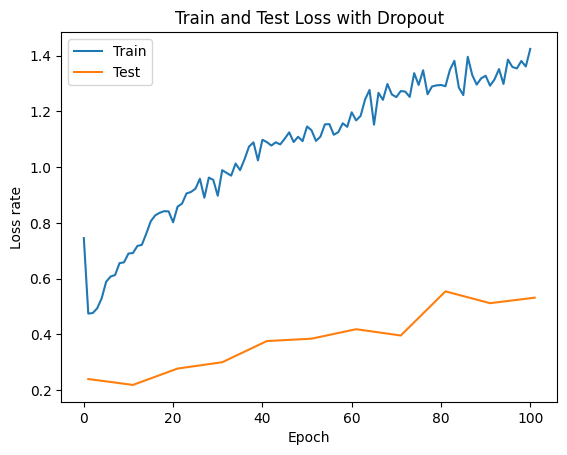

In [11]:
plt.plot(np.arange(n_epochs + 1), train_loss, label="Train")
plt.plot(np.arange(1, n_epochs + 2, 10), test_loss, label="Test")
plt.title("Train and Test Loss with Dropout")
plt.xlabel("Epoch")
plt.ylabel("Loss rate")
plt.legend()

The test loss is evaluated with a different configuration because dropout is only a training-time regularizer. This approach removes the random masking so that the test score reflects the deterministic network we actually use for predicting.

Compared with part 1, the dropout model does better on the test set: part 1 finishes at about 9.01e-01 test loss, while the dropout finishes at about 5.31e-01. So dropout improves the test error.

## Part 3: Parametric ReLU

In [12]:
# define PReLU
def PRelu(X, a):
    return torch.where(X > 0, X, a * X)

# initialize learnable parameters
a1 = torch.ones(625) * 0.25
a1.requires_grad = True

a2 = torch.ones(625) * 0.25
a2.requires_grad = True

# create PReLU model
def prelu_model(X, w_h, w_h2, w_o, a1, a2):
    h = PRelu(X @ w_h, a1)

    h2 = PRelu(h @ w_h2, a2)

    return h2 @ w_o

In [13]:
# reinitializing weights
w_h = init_weights((784, 625))
w_h2 = init_weights((625, 625))
w_o = init_weights((625, 10))

# add parameters to optimizer
optimizer = RMSprop(params=[w_h, w_h2, w_o, a1, a2])

n_epochs = 100

train_loss = []
test_loss = []

# put this into a training loop over 100 epochs
for epoch in range(n_epochs + 1):
    train_loss_this_epoch = []
    for idx, batch in enumerate(train_dataloader):
        x, y = batch

        # our model requires flattened input
        x = x.reshape(batch_size, 784)
        # feed input through model
        noise_py_x = prelu_model(x, w_h, w_h2, w_o, a1, a2)

        # reset the gradient
        optimizer.zero_grad()

        # the cross-entropy loss function already contains the softmax
        loss = cross_entropy(noise_py_x, y, reduction="mean")

        train_loss_this_epoch.append(float(loss))

        # compute the gradient
        loss.backward()
        # update weights
        optimizer.step()

    train_loss.append(np.mean(train_loss_this_epoch))

    # test periodically
    if epoch % 10 == 0:
        print(f"Epoch: {epoch}")
        print(f"Mean Train Loss for the PReLU Model: {train_loss[-1]:.2e}")
        test_loss_this_epoch = []

        # no need to compute gradients for validation
        with torch.no_grad():
            for idx, batch in enumerate(test_dataloader):
                x, y = batch
                x = x.reshape(batch_size, 784)
                noise_py_x = prelu_model(x, w_h, w_h2, w_o, a1, a2)

                loss = cross_entropy(noise_py_x, y, reduction="mean")
                test_loss_this_epoch.append(float(loss))

        test_loss.append(np.mean(test_loss_this_epoch))

        print(f"Mean Test Loss for the PReLU Model:  {test_loss[-1]:.2e}")

Epoch: 0
Mean Train Loss for the PReLU Model: 4.61e-01
Mean Test Loss for the PReLU Model:  2.18e-01
Epoch: 10
Mean Train Loss for the PReLU Model: 9.90e-02
Mean Test Loss for the PReLU Model:  2.94e-01
Epoch: 20
Mean Train Loss for the PReLU Model: 7.82e-02
Mean Test Loss for the PReLU Model:  2.29e-01
Epoch: 30
Mean Train Loss for the PReLU Model: 6.81e-02
Mean Test Loss for the PReLU Model:  4.31e-01
Epoch: 40
Mean Train Loss for the PReLU Model: 5.99e-02
Mean Test Loss for the PReLU Model:  3.82e-01
Epoch: 50
Mean Train Loss for the PReLU Model: 4.59e-02
Mean Test Loss for the PReLU Model:  4.64e-01
Epoch: 60
Mean Train Loss for the PReLU Model: 4.25e-02
Mean Test Loss for the PReLU Model:  5.05e-01
Epoch: 70
Mean Train Loss for the PReLU Model: 3.69e-02
Mean Test Loss for the PReLU Model:  5.36e-01
Epoch: 80
Mean Train Loss for the PReLU Model: 3.18e-02
Mean Test Loss for the PReLU Model:  5.95e-01
Epoch: 90
Mean Train Loss for the PReLU Model: 3.61e-02
Mean Test Loss for the PReL

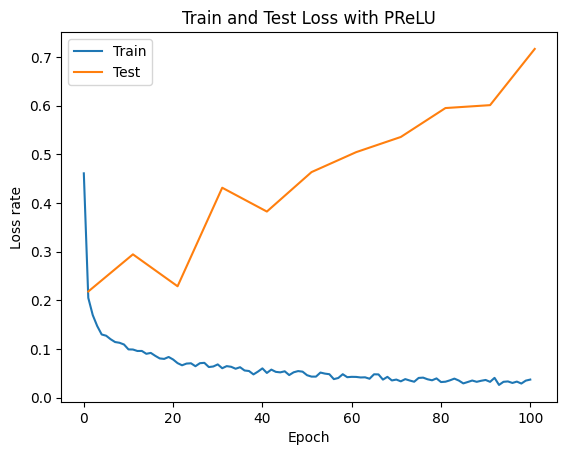

In [14]:
plt.plot(np.arange(n_epochs + 1), train_loss, label="Train")
plt.plot(np.arange(1, n_epochs + 2, 10), test_loss, label="Test")
plt.title("Train and Test Loss with PReLU")
plt.xlabel("Epoch")
plt.ylabel("Loss rate")
plt.legend()

For the part 1 model the test loss was 9.01e-01 which is the highest test error (worst generalization). For the part 2 (dropout) the test loss was 5.31e-01 which is the lowest test error (best generalization). For the last one (PReLU), it is lower training loss than part 1 and better training convergence, however does not show the regularization benefit of dropout. It's final test loss (which is 7.17e-01) sits between part 1 and dropout, and it may overfit without regularization. 